# Tomograf komputerowy - Raport

### 1. Skład grupy

Paweł Kociucki 160224
Piotr Rembeza 160176

### 2. Opis rozwiązania

W naszym rozwiązaniu zastosowaliśmy model stożkowy. Zaimplementowaliśmy go za pomocą języka Python oraz takich bibliotek jak: numpy (obliczenia), matplotlib (wizualizacja), datetime (pozyskanie daty), pydicom (obsługa plików DICOM), skimage (konwersja obrazu na bitmapę) oraz ipywidgets i IPython.display (suwaki). Dokładny opis najważniejszych funkcji znajduje się, dla przejrzystości,  w komentarzach kodu źródłowego.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
from skimage import io, color, draw
from pydicom.dataset import Dataset, FileDataset
import pydicom.uid
from pydicom.uid import ExplicitVRLittleEndian
import math
from skimage.util import img_as_ubyte
from skimage.exposure import rescale_intensity
import ipywidgets as widgets
from IPython.display import display
name = widgets.Text(description="Imię i  nazwisko:")
id = widgets.Text(description="ID:")
comment = widgets.Text(description="Komentarz:")
display(name, id, comment)
def pobierz(_):
    print(name.value, id.value, comment.value)

slider1 = widgets.FloatSlider(
    value=0.5,
    min=0.1,
    max=1,
    step=0.1,
    description='Krok:'
)
display(slider1)
krok=slider1.value
slider2 = widgets.IntSlider(
    value=250,
    min=100,
    max=500,
    step=10,
    description='Detektory:'
)
display(slider2)

detektory = slider2.value
slider3 = widgets.IntSlider(
    value=180,
    min=90,
    max=270,
    step=10,
    description='Rozpiętość kątowa:'
)
display(slider3)
rozpietosc_katowa = slider3.value
checkbox = widgets.Checkbox(
    value=False,
    description='Filtrowanie'
)

display(checkbox)
czy_filtr=checkbox.value
nazwaPliku = widgets.Text(description="DICOM:")
nazwaPlikuJPG = widgets.Text(description="JPG:")
wynikowy=widgets.Text(description="Plik wynikowy:")
display(nazwaPliku,nazwaPlikuJPG,wynikowy)
patientData=dict()



Text(value='', description='Imię i  nazwisko:')

Text(value='', description='ID:')

Text(value='', description='Komentarz:')

FloatSlider(value=0.5, description='Krok:', max=1.0, min=0.1)

IntSlider(value=250, description='Detektory:', max=500, min=100, step=10)

IntSlider(value=180, description='Rozpiętość kątowa:', max=270, min=90, step=10)

Checkbox(value=False, description='Filtrowanie')

Text(value='', description='DICOM:')

Text(value='', description='JPG:')

Text(value='', description='Plik wynikowy:')

In [2]:
#Przypisanie wartości suwaków do zmiennych
krok=slider1.value
detektory = slider2.value
rozpietosc_katowa = slider3.value
czy_filtr=checkbox.value
nazwaPliku=nazwaPliku.value
nazwaPlikuJPG=nazwaPlikuJPG.value
wynikowy=wynikowy.value
patientData["PatientName"]=name.value
patientData["PatientID"]=id.value
patientData["ImageComments"]=comment.value
print("Krok: ", krok)
print("Detektory: ", detektory)
print("Rozpiętość kątowa: ", rozpietosc_katowa)
print("Filtrowanie: ", czy_filtr)
print("Imię i nazwisko: ",name.value)
print("ID: ",id.value)
print("Komentarz: ",comment.value)
print("Nazwa pliku DICOM: ",nazwaPliku)
print("Nazwa pliku JPG: ",nazwaPlikuJPG)
print("Nazwa pliku wynikowego: ",wynikowy)

Krok:  0.5
Detektory:  250
Rozpiętość kątowa:  180
Filtrowanie:  False
Imię i nazwisko:  Jan Kowal
ID:  1234
Komentarz:  asdf
Nazwa pliku DICOM:  shepp_logan.dcm
Nazwa pliku JPG:  
Nazwa pliku wynikowego:  wynik.dcm


In [3]:
def convert_image_to_ubyte(img): #konwersja obrazu do wersji 8-bitowej (znormalizowanej do przedziału [0,1])
    return img_as_ubyte(rescale_intensity(img, out_range=(0.0, 1.0)))
def save_as_dicom(file_name, img, patient_data): #Zapis do pliku DICOM
    img_converted = convert_image_to_ubyte(img)
    #=====Uzupełnienie metadanych pliku======
    file_meta = pydicom.Dataset() #stworzenie struktury przechowującej metadane
    file_meta.MediaStorageSOPClassUID = pydicom.uid.SecondaryCaptureImageStorage #typem danych jest SecondaryCapture (zwykły obraz)
    file_meta.MediaStorageSOPInstanceUID = pydicom.uid.generate_uid() #generacja unikalnego id pliku
    file_meta.ImplementationClassUID = pydicom.uid.generate_uid() #generacja unikalnego id implementacji
    file_meta.TransferSyntaxUID = pydicom.uid.ImplicitVRLittleEndian #format zapisu danych (Little Endian, zapis VR)
    ds = FileDataset(file_name, {}, file_meta=file_meta, preamble=b"\0" * 128) #stworzenie datasetu dla naszego pliku, dodatkowo przypisanie metadanych i preambuły
    #============Zapis podstawowych danych (daty, czasu, imienia i nazwiska pacjenta, jego ID i komentarz)=====
    now = datetime.datetime.now()
    ds.ContentDate = now.strftime('%Y%m%d')
    ds.ContentTime = now.strftime('%H%M%S')

    ds.PatientName = patient_data["PatientName"]
    ds.PatientID = patient_data["PatientID"]
    ds.ImageComments = patient_data["ImageComments"]
    print("=====TAGI PLIKU WYNIKOWEGO====")
    print("PatientName: ",ds.PatientName)
    print("PatientID: ",ds.PatientID)
    print("ImageComments: ",ds.ImageComments)
    #====Najważniejsze parametry dotyczące obrazu====
    ds.Rows, ds.Columns = img_converted.shape #wymiary obrazu
    ds.SamplesPerPixel = 1 #obraz monochromatyczny
    ds.PhotometricInterpretation = "MONOCHROME2" #sposób kodowania kolorów
    ds.PixelRepresentation = 0 #dane nieujemne (bez znaku)
    ds.HighBit = 7 #najwyższa możliwa wartość
    ds.BitsStored = 8 #liczba przechowywanych bitów na piksel
    ds.BitsAllocated = 8 #liczba bitów w pamięci


    #Sprawdzenie czy metadane spełniają standardy DICOM
    pydicom.dataset.validate_file_meta(ds.file_meta, enforce_standard=True)

    ds.PixelData = img_converted.tobytes() #zmiana obrazu na wersję bajtową

    ds.save_as(file_name, enforce_file_format=True) #zapis do pliku DICOM wymuszając zgodność z DICOM
def read_dicom_normalized(path): #czytanie pliku DICOM
    ds = pydicom.dcmread(path)
    print("=====TAGI PLIKU WEJŚCIOWEGO=====")
    print("PatientName: ",ds.PatientName)
    print("PatientID: ",ds.PatientID)
    print("ImageComments: ",ds.ImageComments)
    image = ds.pixel_array.astype(np.float32)
    #=====Normalizacja=====
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val > min_val:
        image_norm = (image - min_val) / (max_val - min_val)
    else:
        image_norm = np.zeros_like(image)
    return image_norm

In [ ]:
#Obliczanie błędu średniokwadratowego
def blad_sredniokwadratowy(obraz_wej, obraz_wyj):
    obraz_wej = obraz_wej.astype(np.float64)
    obraz_wyj = obraz_wyj.astype(np.float64)
    #podstawienie pod wzór (średnia z kwadratów różnic na poszczególnych bajtach pomiędzy obrazem wejściowym i wyjściowym)
    return np.sqrt(np.mean((obraz_wej - obraz_wyj) ** 2))
#Transformata Radona
def transformataRadona(obraz, krok, detektory, rozpietosc):
    #=====Deklaracja początkowych parametrów (wysokość i szerokość obrazu, promień okręgu opisanego, połowa wysokości i szerokości)
    h, w = obraz.shape[:2]
    r = 0.5 * np.sqrt(h**2 + w**2)
    cx = w / 2
    cy = h / 2

    theta = 0
    sinogram = []
    wynik=[]
    #pozyskanie odczytów (tak długo aż tomograf nie obróci się o 180 stopni)
    while theta <= 180:
        row = []
        theta_rad = np.radians(theta)

        # pozycja emitera
        Xe = cx + r * np.cos(theta_rad)
        Ye = cy + r * np.sin(theta_rad)

        start_angle = theta_rad + np.pi - np.radians(rozpietosc) / 2
        for i in range(detektory):
            alpha = start_angle + i * np.radians(rozpietosc) / (detektory - 1)

            # pozycja detektora
            Xd = cx + r * np.cos(alpha)
            Yd = cy + r * np.sin(alpha)

            # punkty na promieniu (algorytm Bresenhama)
            punkty = draw.line_nd((int(Ye), int(Xe)), (int(Yd), int(Xd)))
            #zapis odczytu do sinogramu dla każdego detektora
            suma = 0.0
            for k in range(len(punkty[0])):
                y = punkty[0][k]
                x = punkty[1][k]
                if 0 <= x < w and 0 <= y < h:
                    suma += obraz[y, x]  #sumujemy jasności
            row.append(suma)
        #zapis całego odczytu
        sinogram.append(row)
        wynik.append(np.array(sinogram))
        theta += krok
    return wynik

# ========================================================================================
try:
    image = read_dicom_normalized(nazwaPliku)
except:
    image = io.imread(nazwaPlikuJPG)
finally:
    if len(image.shape) == 3:
        image = color.rgb2gray(image)

sinogramy = transformataRadona(image, krok, detektory, rozpietosc_katowa)
for i in range(len(sinogramy)):
  sinogramy[i] /= np.max(sinogramy[i])


slider_sin = widgets.IntSlider(
    value=len(sinogramy),
    min=1,
    max=len(sinogramy),
    step=1,
    description='Etap:'
)
def pokaz_sin(pos):
  fig, ax = plt.subplots(1,2, figsize=(12,5))

  ax[0].imshow(image, cmap='gray')
  ax[0].set_title("Obraz wejściowy")
  ax[0].axis("off")
  ax[1].imshow(sinogramy[pos-1], cmap='gray', aspect='auto', extent=(0, 180, 0, sinogramy[pos-1].shape[0]))
  ax[1].set_title("Sinogram")
  ax[1].set_xlabel("Kąt (stopnie)")
  ax[1].set_ylabel("Pozycja detektora")
  plt.tight_layout()
  plt.show()
widgets.interact(pokaz_sin,pos=slider_sin)


=====TAGI PLIKU WEJŚCIOWEGO=====
PatientName:  Doe^John
PatientID:  42
ImageComments:  what a lovely image we have here...


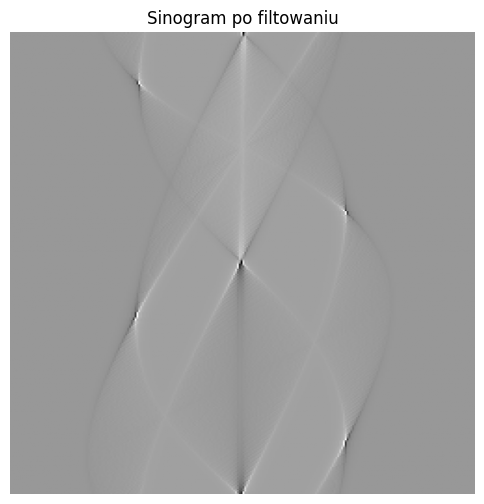

In [ ]:
def kernel(n): #generacja filtra
    h = np.zeros(n)
    center = n // 2
    #====tworzenie filtra zgodnie z definicją
    for k in range(-center, center):
        if k == 0:
            h[center] = 1
        elif k % 2 != 0:
            h[center + k] = -4 / (np.pi**2 * k**2)
        else:
            h[center + k] = 0

    return h

def filtruj_sinogram(sinogram): #filtrowanie sinogramu
    filtr = kernel(21) #rozmiar maski - 21
    wynik = np.zeros_like(sinogram)
    #Dokonujemy splotu dla każdego wiersza sinogramu z naszym filtrem
    for i in range(sinogram.shape[0]):
        wynik[i] = np.convolve(sinogram[i], filtr, mode='same')

    return wynik
if czy_filtr==True:
  sinogramy[-1] = filtruj_sinogram(sinogramy[-1])
  plt.figure(figsize=(6,6))
  plt.imshow(sinogramy[-1], aspect='auto', cmap='gray', extent=(0, 180, 0, sinogramy[-1].shape[0]))
  plt.title("Sinogram po filtowaniu")
  plt.axis("off")
  plt.show()

Iteracja: 10 	RMSE: 0.313310018371428
Iteracja: 20 	RMSE: 0.3091232463150758
Iteracja: 30 	RMSE: 0.3047368351940839
Iteracja: 40 	RMSE: 0.2997270919596677
Iteracja: 50 	RMSE: 0.2940357222546411
Iteracja: 60 	RMSE: 0.2888918398049569
Iteracja: 70 	RMSE: 0.2853362634840632
Iteracja: 80 	RMSE: 0.2826732617680708
Iteracja: 90 	RMSE: 0.2806985252889986
Iteracja: 100 	RMSE: 0.27796947294495755
Iteracja: 110 	RMSE: 0.2745820033803076
Iteracja: 120 	RMSE: 0.26899625726657983
Iteracja: 130 	RMSE: 0.26577901733426984
Iteracja: 140 	RMSE: 0.26333019340617564
Iteracja: 150 	RMSE: 0.261320517358356
Iteracja: 160 	RMSE: 0.26174861762641416
Iteracja: 170 	RMSE: 0.26362941753159413
Iteracja: 180 	RMSE: 0.2648539301435684
Iteracja: 190 	RMSE: 0.26142304247963305
Iteracja: 200 	RMSE: 0.2572372988706202
Iteracja: 210 	RMSE: 0.25381663184322345
Iteracja: 220 	RMSE: 0.25082738893040685
Iteracja: 230 	RMSE: 0.24814152647311022
Iteracja: 240 	RMSE: 0.24620991560790934
Iteracja: 250 	RMSE: 0.24484579641471513

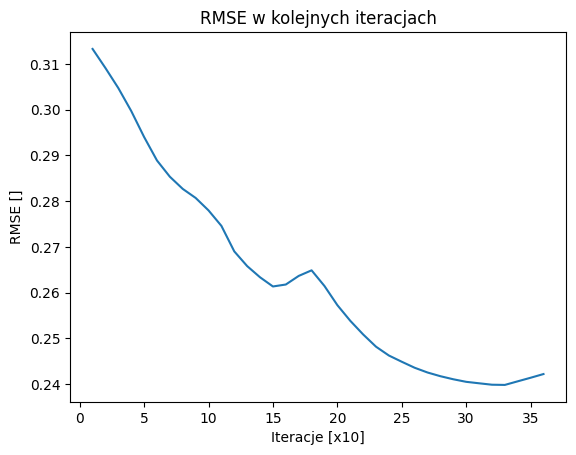

interactive(children=(IntSlider(value=362, description='Etap:', max=362, min=1), Output()), _dom_classes=('wid…

In [ ]:
def odwrotnaTransformataRadona(sinogram, obraz_shape, krok, detektory, rozpietosc,pokaz):
    #====Deklaracja zmiennych - analogicznie jak w transformacji Radona
    h, w = obraz_shape
    rekonstrukcje=[]
    rekonstrukcja = np.zeros((h, w))
    r = 0.5 * np.sqrt(h**2 + w**2)
    cx = w / 2
    cy = h / 2

    theta = 0
    j = 0
    rekonstrukcje.append(rekonstrukcja.copy())
    bledy=[]
    #odczyt z sinogramu i zapis do pustego obrazu
    #analogicznie jak dla zapisu do sinogramu
    while theta <= 180 and j < sinogram.shape[0]:
        theta_rad = np.radians(theta)

        # pozycja emitera
        Xe = cx + r * np.cos(theta_rad)
        Ye = cy + r * np.sin(theta_rad)
        start_angle = theta_rad + np.pi - np.radians(rozpietosc) / 2

        for i in range(detektory):
            #pozycja detektorów
            alpha = start_angle + i * np.radians(rozpietosc) / (detektory - 1)
            Xd = cx + r * np.cos(alpha)
            Yd = cy + r * np.sin(alpha)

            punkty = draw.line_nd((int(Ye), int(Xe)), (int(Yd), int(Xd)))
            wartosc = sinogram[j][i]
            #Zapis informacji z sinogramu do obrazu wynikowego
            for k in range(len(punkty[0])):
                y = punkty[0][k]
                x = punkty[1][k]
                if 0 <= x < w and 0 <= y < h:
                    rekonstrukcja[y, x] += wartosc
        rekonstrukcje.append(rekonstrukcja.copy())
        theta += krok
        j += 1
        #Obliczenie MSE dla co dziesiątego obrazu
        if pokaz==True:
          if j % 10 == 0:
              rek_norm = rekonstrukcja / np.max(rekonstrukcja)
              a=blad_sredniokwadratowy(image, rek_norm)
              print("Iteracja:", j, "\tRMSE:", a)
              bledy.append(a)
    if pokaz==True:
      x=list(range(1,len(bledy)+1))
      plt.plot(x,bledy)
      plt.title("RMSE w kolejnych iteracjach")
      plt.xlabel("Iteracje [x10]")
      plt.ylabel("RMSE []")
      plt.show()
    return rekonstrukcje

reconstructed = odwrotnaTransformataRadona(sinogramy[-1], image.shape, krok, detektory, rozpietosc_katowa,True)
slider = widgets.IntSlider(
    value=len(reconstructed),
    min=1,
    max=len(reconstructed),
    step=1,
    description='Etap:'
)
def pokaz(pos):
  plt.figure(figsize=(6,6))
  plt.imshow(reconstructed[pos-1], cmap='gray')
  plt.title("Rekonstrukcja (Back Projection)"+str(pos))
  plt.axis("off")
  plt.show()
widgets.interact(pokaz,pos=slider)
save_as_dicom(wynikowy,reconstructed[-1],patientData)


In [ ]:
#======ZMIENNE DETEKTORY======
krok=1
rozpietosc_katowa=180
bledy=[]
detektory=[]
for i in range(90,721,90):
  sinogramy=transformataRadona(image, krok, i, rozpietosc_katowa)
  sinogramy[-1] = filtruj_sinogram(sinogramy[-1])
  reconstructed = odwrotnaTransformataRadona(sinogramy[-1], image.shape, krok, i, rozpietosc_katowa,False)
  rec_norm = reconstructed[-1] / np.max(reconstructed[-1])
  pokaz(len(reconstructed))
  bledy.append(blad_sredniokwadratowy(image,rec_norm))
  detektory.append(i)
plt.plot(detektory,bledy)
plt.xlabel("Liczba detektorów")
plt.ylabel("RMSE")
plt.show()


KeyboardInterrupt: 

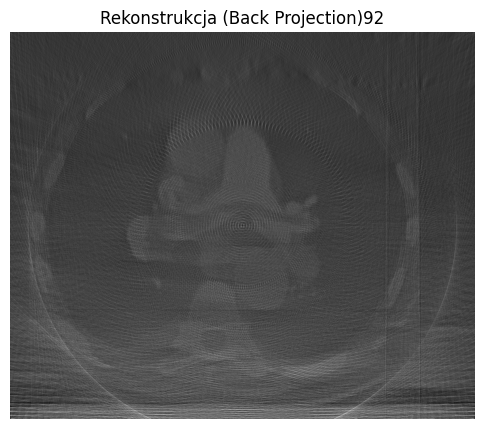

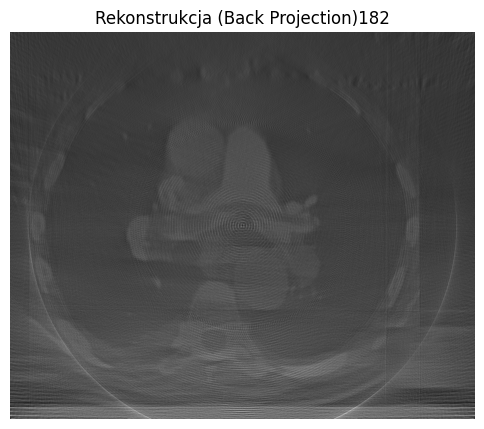

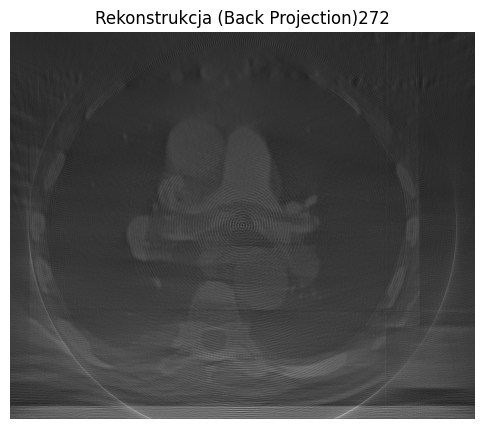

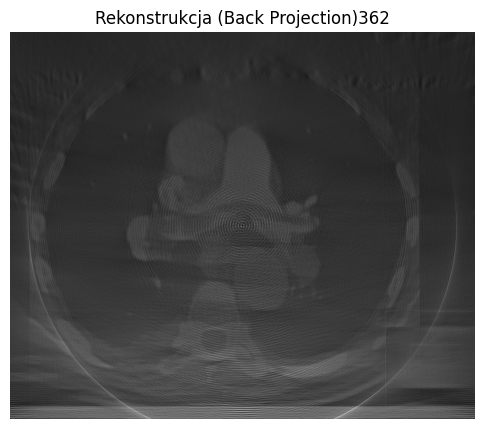

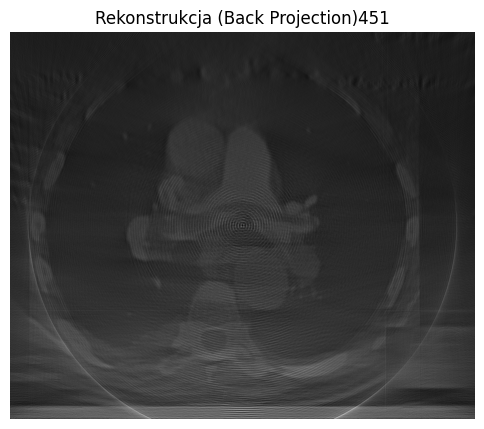

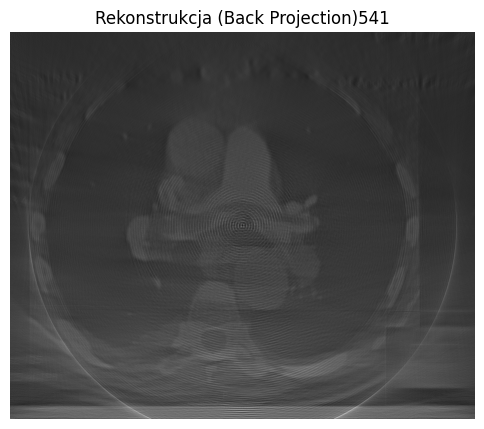

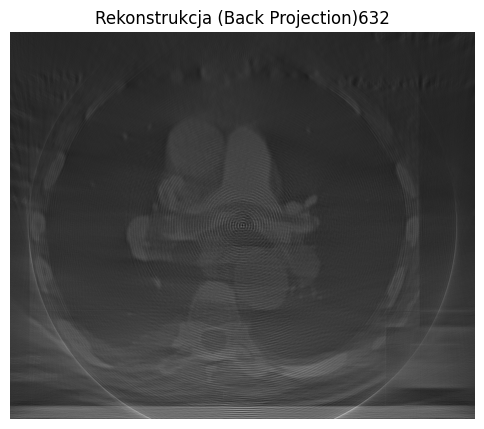

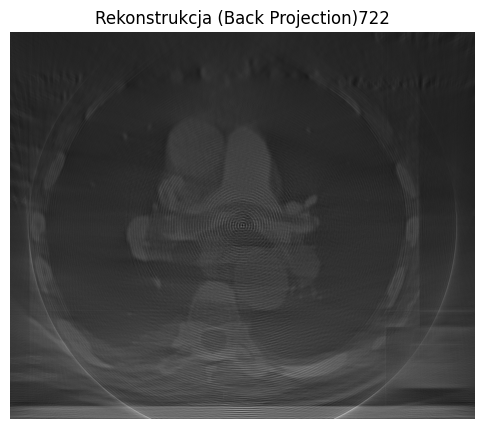

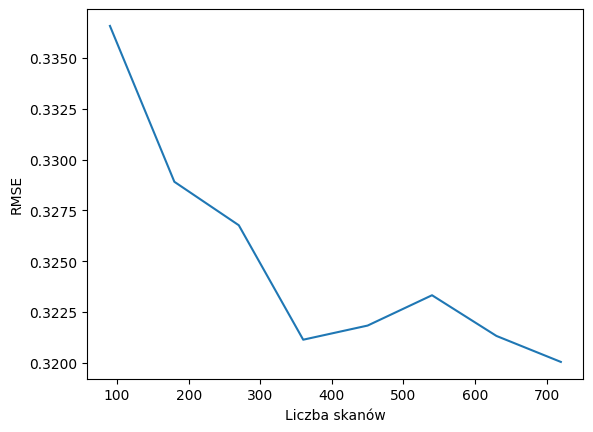

In [ ]:
#======ZMIENNA LICZBA SKANOW======
liczba_skanow=[]
rozpietosc_katowa=180
bledy2=[]
detektory2=180
for i in range(90,721,90):
  krok2=180/i
  sinogramy=transformataRadona(image, krok2, detektory2, rozpietosc_katowa)
  sinogramy[-1] = filtruj_sinogram(sinogramy[-1])
  reconstructed = odwrotnaTransformataRadona(sinogramy[-1], image.shape, krok2, detektory2, rozpietosc_katowa,False)
  pokaz(len(reconstructed))
  rec_norm = reconstructed[-1] / np.max(reconstructed[-1])
  bledy2.append(blad_sredniokwadratowy(image,rec_norm))
  liczba_skanow.append(i)
plt.plot(liczba_skanow,bledy2)
plt.xlabel("Liczba skanów")
plt.ylabel("RMSE")
plt.show()

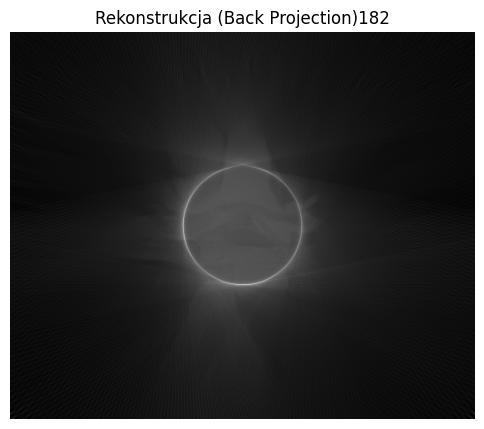

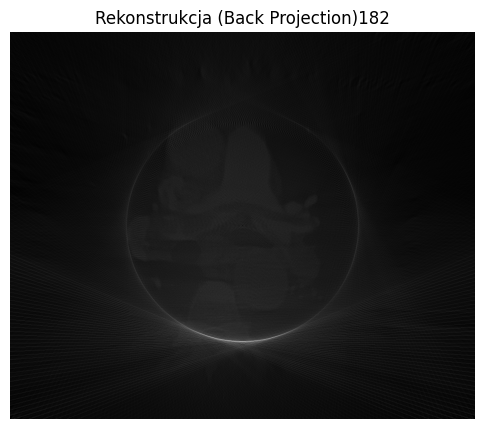

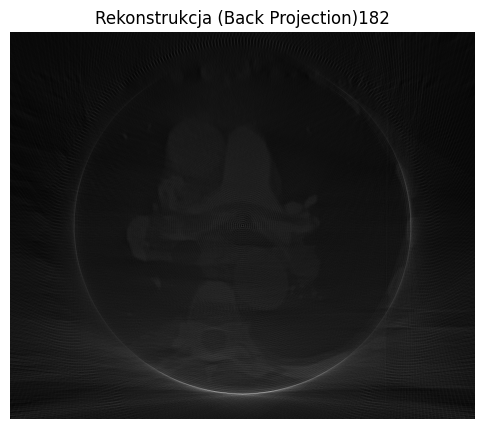

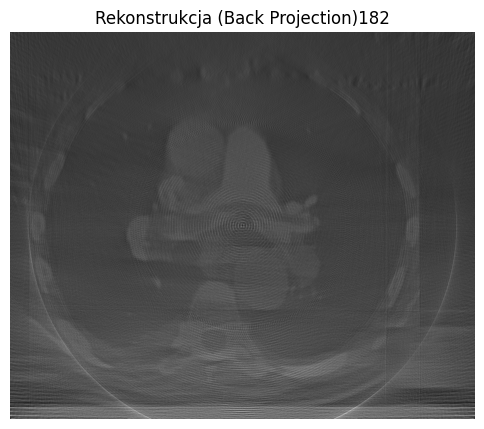

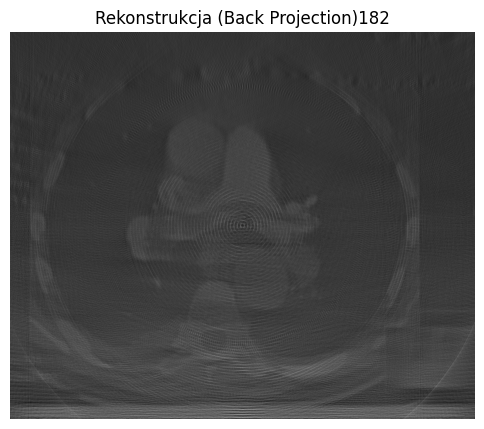

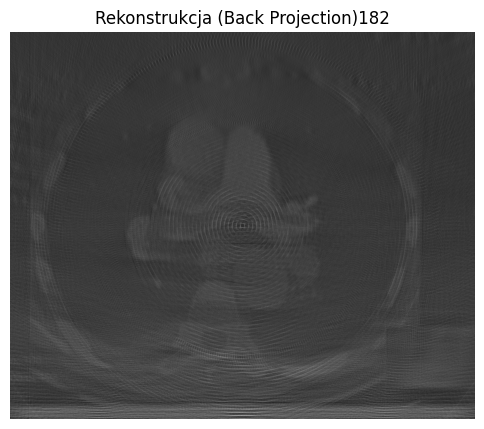

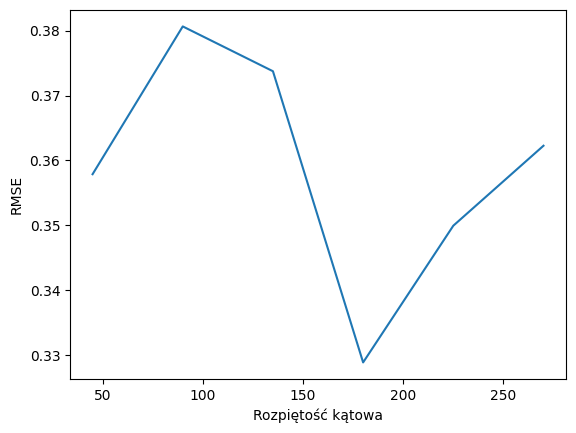

In [ ]:
#======ZMIENNA ROZPIĘTOŚĆ KĄTOWA======
rozpietosci=[]
bledy3=[]
detektory3=180
krok3=1
for i in range(45,271,45):
  sinogramy=transformataRadona(image, krok3, detektory3, i)
  sinogramy[-1] = filtruj_sinogram(sinogramy[-1])
  reconstructed = odwrotnaTransformataRadona(sinogramy[-1], image.shape, krok3, detektory3, i,False)
  pokaz(len(reconstructed))
  rec_norm = reconstructed[-1] / np.max(reconstructed[-1])
  bledy3.append(blad_sredniokwadratowy(image,rec_norm))
  rozpietosci.append(i)
plt.plot(rozpietosci,bledy3)
plt.xlabel("Rozpiętość kątowa")
plt.ylabel("RMSE")
plt.show()

### 3a. Eksperyment ze zmiennymi parametrami
W celu zbadania zachowania symulatora tomografu, przeprowadziliśmy eksperyment polegający na zmianie jednego parametru przy ustalonych wartościach domyślnych pozostałych atrybutów. Domyślnie mamy:


*   liczba detektorów = 180
*   rozpiętość kątowa = 180 stopni
*   liczba skanów = 180

Nasz eksperyment dotyczy zmiany każdego parametru, zatem de facto przeprowadziliśmy trzy podeksperymenty. W każdym z nich zapisaliśmy wartości RMSE i pokazaliśmy je na wykresie w zależności od zmiennego parametru, a także wyniki dla jego początkowej i końcowej wartości.

**I Zmienna liczba detektorów**

W naszym przypadku liczba detektorów należała do zakresu [90,720] z krokiem 90

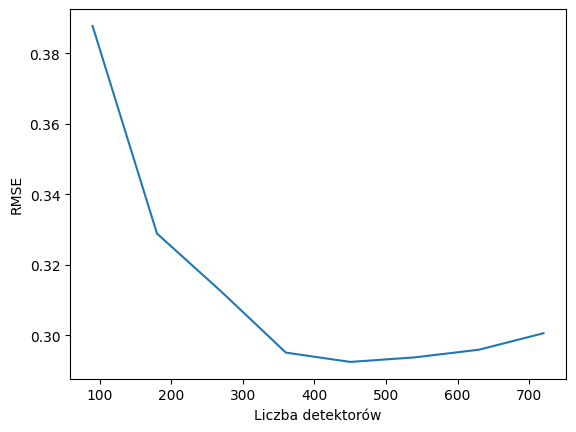



Jak widać, wraz z rosnącą liczbą detektorów spada błąd średniokwadratowym, czyli dokładność rośnie. Widać to również na obrazach wynikowych, których jakość dla większej liczby detektorów jest znacznie lepsza. Bierze się to oczywiście z sumarycznie większej liczby przeprowadzonych pomiarów, co naturalnie poprawia dokładność odwzorowania.

Obraz dla minimalnej liczby detektorów:

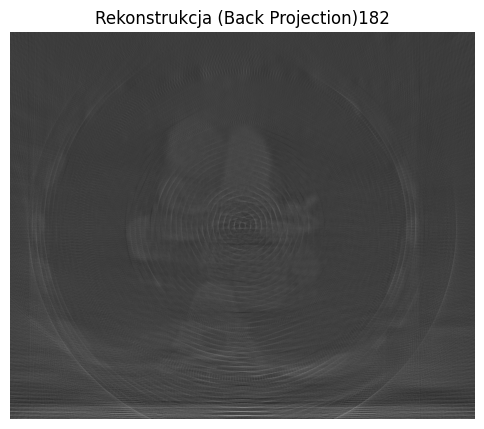

Obraz dla maksymalnej liczby detektorów:

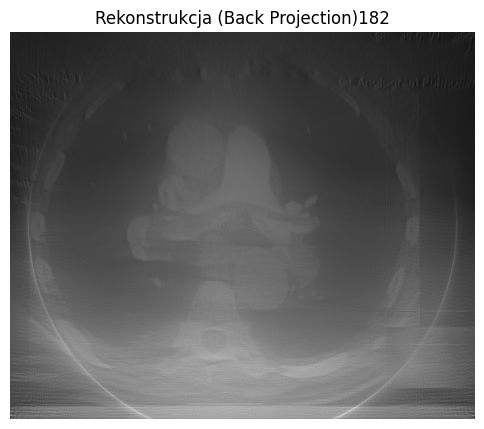

**II Zmienna liczba skanów**

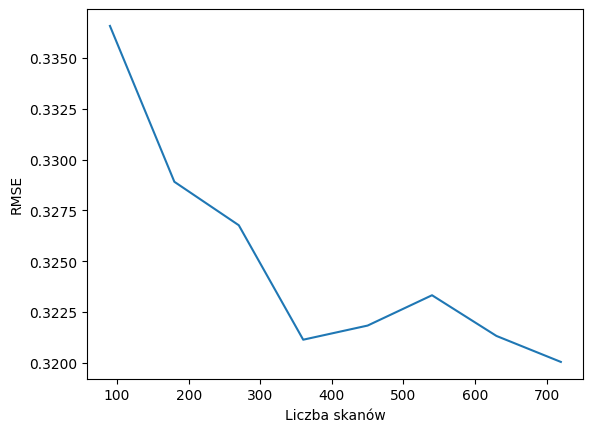
W tym przypadku liczba skanów należała do przedziału [90,720]  z krokiem 90
Zgodnie z oczekiwaniami, wraz z rosnącą liczbą skanów dokładność obrazu rośnie, co wynika z podobnych przyczyn jak w przypadku liczby detektorów (większa liczba pomiarów). Zgadza się to również ze wzrostem jakości obrazu. Poniżej zdjęcia dla minimalnej i maksymalnej liczby skanów.

Obraz dla minimalnej liczby skanów:

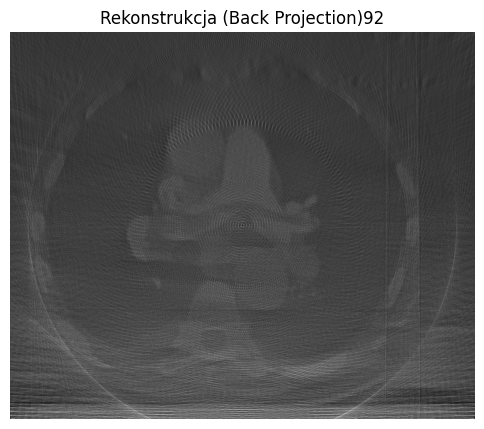

Obraz dla maksymalnej liczby skanów:

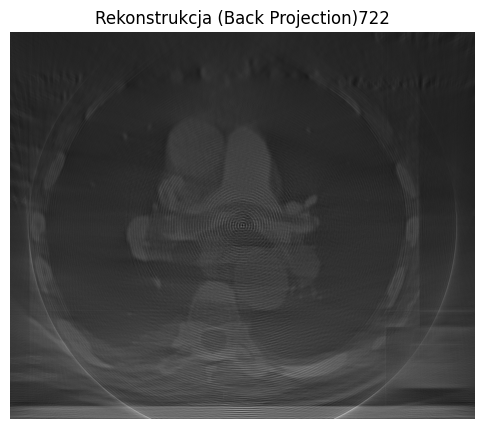

**III Zmienna rozpiętość kątowa**

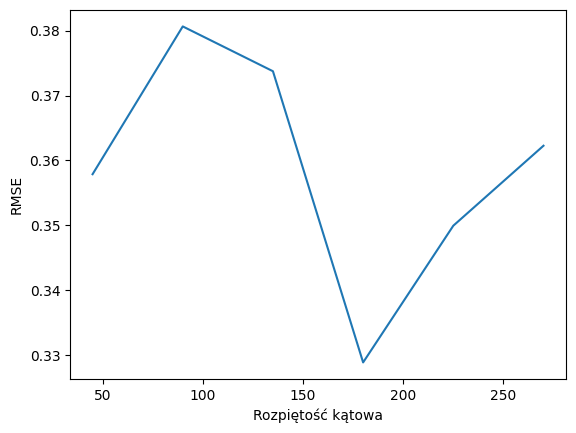

W tym przypadku rozpiętość wachlarza mieściła się w zakresie [45,270] z krokiem 45.

Tutaj również wyniki są zgodne z oczekiwaniami. Błąd średniokwadratowy spada do osiągnięcia minimum dla 180 stopni, po czym znowu rośnie. Wynika to z tego, że dla większych rozpiętości dochodzi do redundancji pomiarów (niektóre pomiary zaczynają się dublować). Ponownie przebieg wykresu znajduje odzwierciedlenie w jakości obrazów.

Obraz dla minimalnej rozpiętości wachlarza:

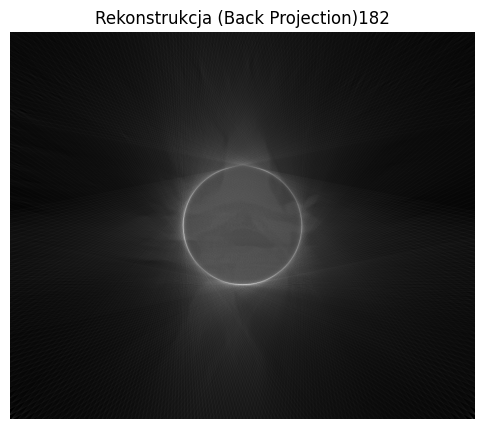

Obraz dla 180 stopni:

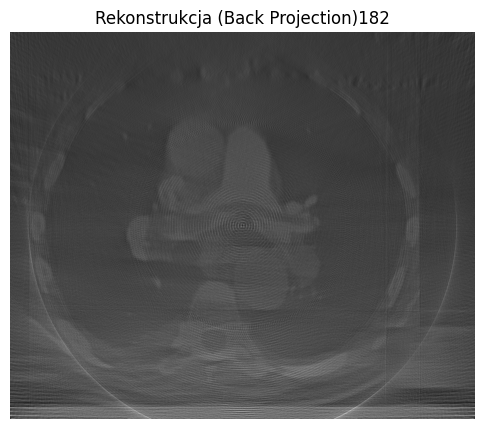

Obraz dla maksymalnej rozpiętości wachlarza:

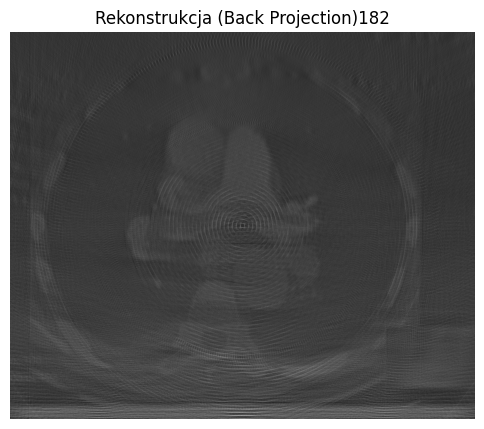

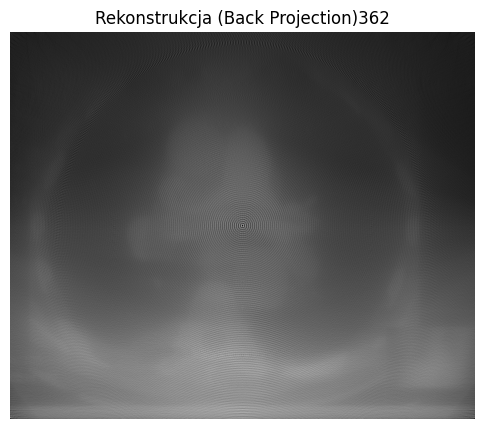

Bez filtrowania:  0.3049723721388878


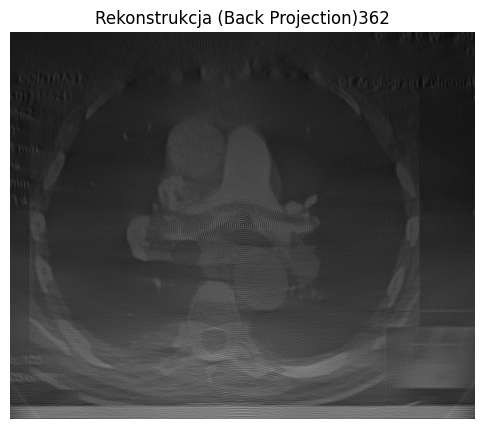

Z filtrowaniem:  0.29541480729528424


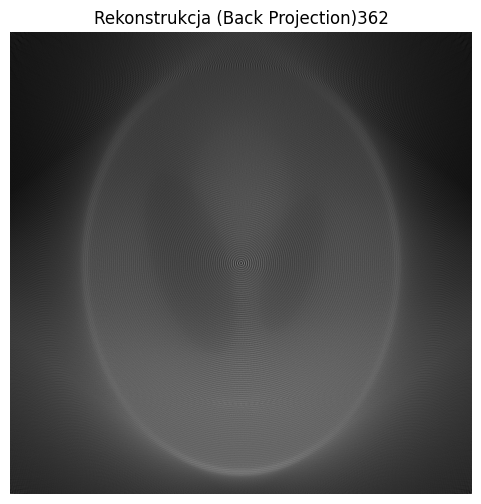

Bez filtrowania:  0.23896642351485162


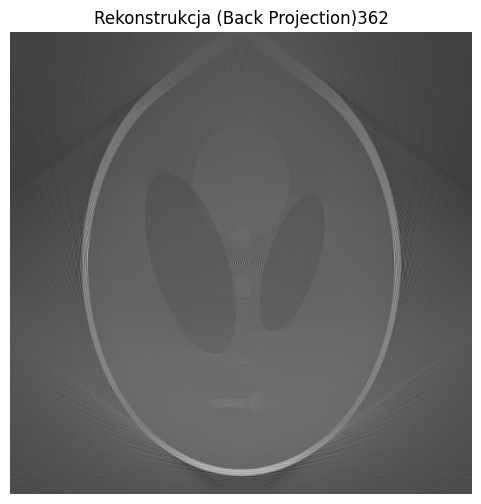

Z filtrowaniem:  0.1857633482267355


In [ ]:
detektory4=360
krok4=0.5
rozpietosc4=270
nazwaPliku = "dicom/SADDLE_PE.dcm"
image = read_dicom_normalized(nazwaPliku)
sinogramy=transformataRadona(image, krok4, detektory4, rozpietosc4)
reconstructed = odwrotnaTransformataRadona(sinogramy[-1], image.shape, krok4, detektory4, rozpietosc4,False)
pokaz(len(reconstructed))
rec_norm = reconstructed[-1] / np.max(reconstructed[-1])
print("Bez filtrowania: ",blad_sredniokwadratowy(image,rec_norm))
sinogramy[-1] = filtruj_sinogram(sinogramy[-1])
reconstructed = odwrotnaTransformataRadona(sinogramy[-1], image.shape, krok4, detektory4, rozpietosc4,False)
pokaz(len(reconstructed))
rec_norm = reconstructed[-1] / np.max(reconstructed[-1])
print("Z filtrowaniem: ",blad_sredniokwadratowy(image,rec_norm))
nazwaPliku = "dicom/shepp_logan.dcm"
image = read_dicom_normalized(nazwaPliku)
sinogramy=transformataRadona(image, krok4, detektory4, rozpietosc4)
reconstructed = odwrotnaTransformataRadona(sinogramy[-1], image.shape, krok4, detektory4, rozpietosc4,False)
pokaz(len(reconstructed))
rec_norm = reconstructed[-1] / np.max(reconstructed[-1])
print("Bez filtrowania: ",blad_sredniokwadratowy(image,rec_norm))
sinogramy[-1] = filtruj_sinogram(sinogramy[-1])
reconstructed = odwrotnaTransformataRadona(sinogramy[-1], image.shape, krok4, detektory4, rozpietosc4,False)
pokaz(len(reconstructed))
rec_norm = reconstructed[-1] / np.max(reconstructed[-1])
print("Z filtrowaniem: ",blad_sredniokwadratowy(image,rec_norm))

### 3b. Eksperyment z filtrowaniem
Dla porównania efektów symulacji tomografu z zastosowaniem filtrowania sinogramu oraz bez niego, dokonaliśmy eksperymentu polegającego na rekonstrukcji dwóch wybranych obrazów w dwóch wersjach (z filtrowaniem i bez) oraz policzeniu dla nich RMSE. Wyszły nam następujące wyniki:

Obraz 1 bez filtrowania:

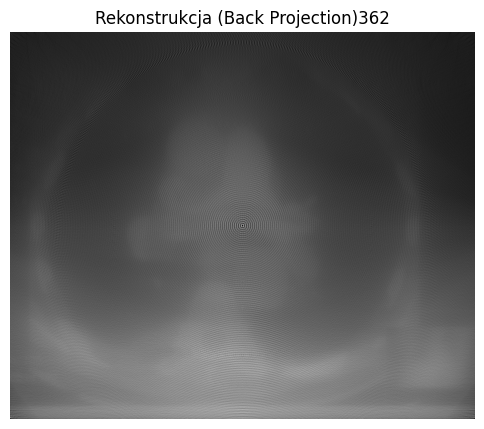

RMSE=0,305

Obraz 1 z filtrowaniem:

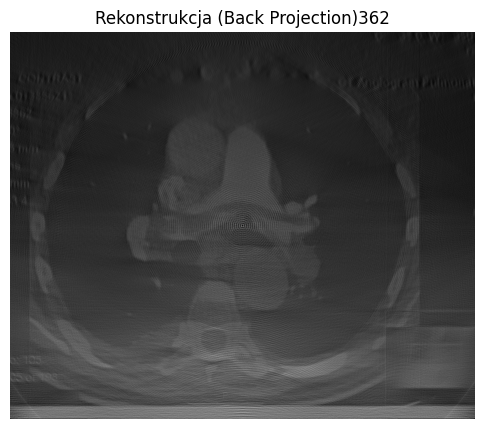

RMSE=0,295

Obraz 2 bez filtrowania:

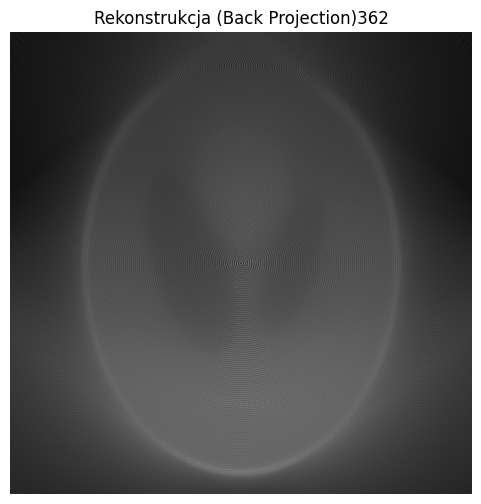

RMSE=0,239

Obraz 2 z filtrowaniem:

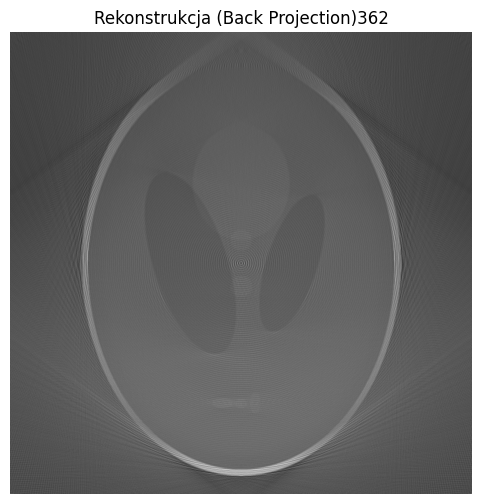

RMSE=0,186

Jak widać, choć różnica w błędzie średniokwadratowym jest niewielka, jakość obrazu z filtrowaniem jest znacznie lepsza niż wersja bez niego. Bierze się to oczywiście z rozmycia obecnego w pierwotnym sinogrami wynikłego z nierównomiernego rozkładu próbek w dziedzinie częstotliwości, które usuwamy poprzez filtrowanie.

### 4. Przykłady
**a) z filtrowaniem**

Obraz wejściowy:

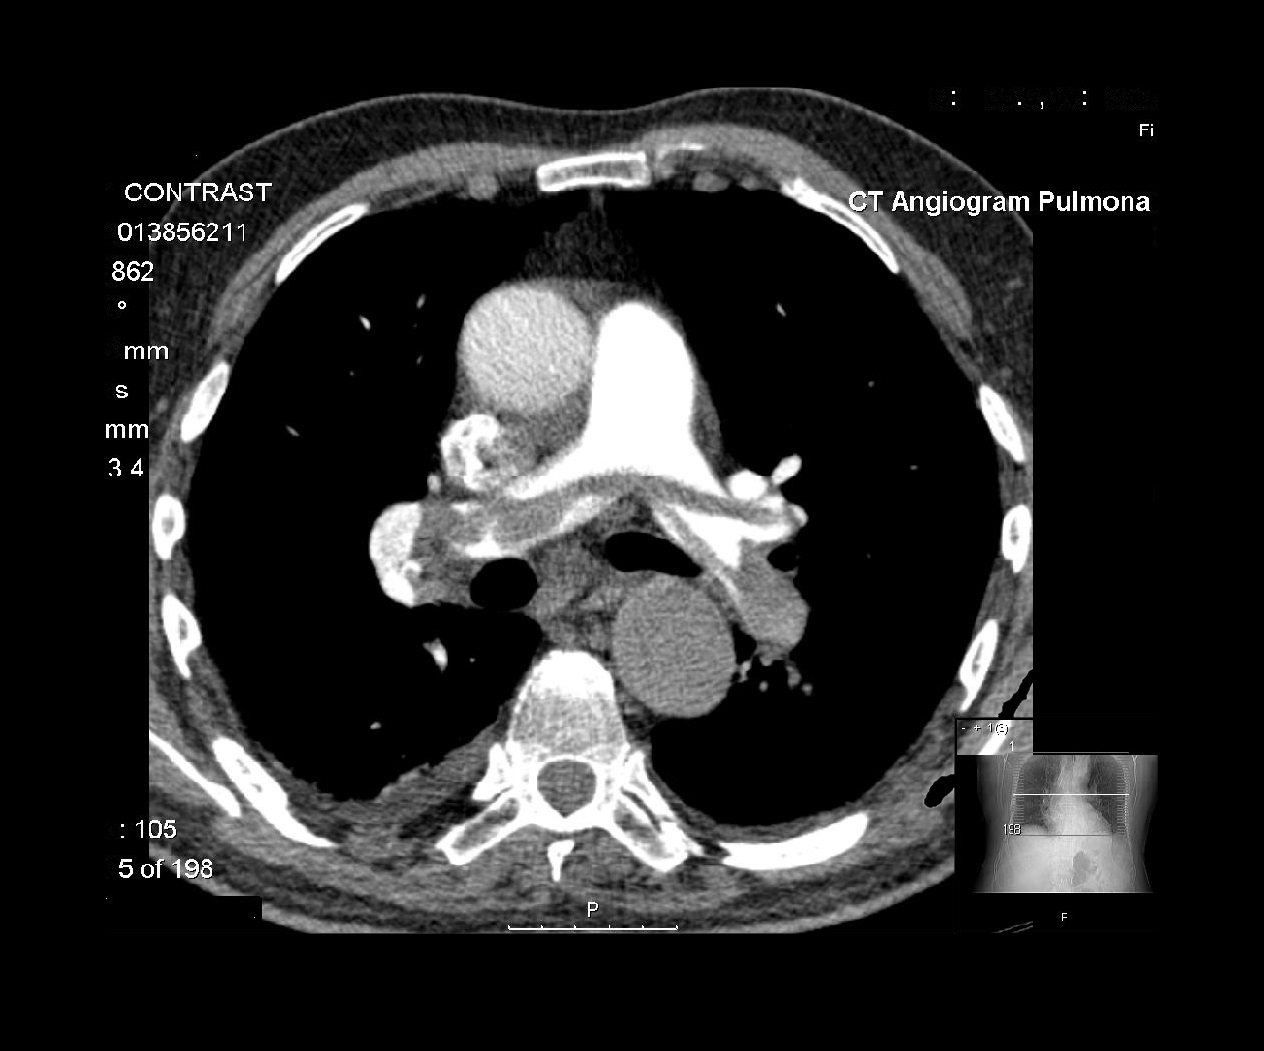

Obraz wyjściowy:

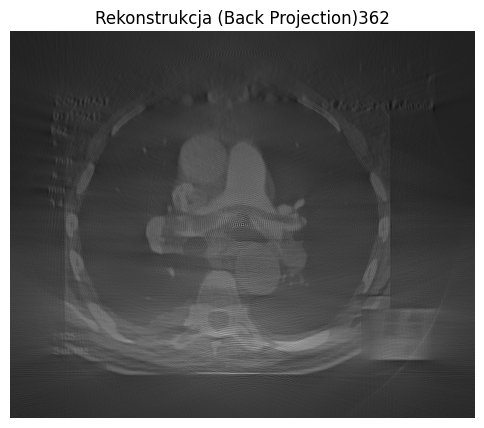

**b) bez filtrowania**

Obraz 1 wejściowy:

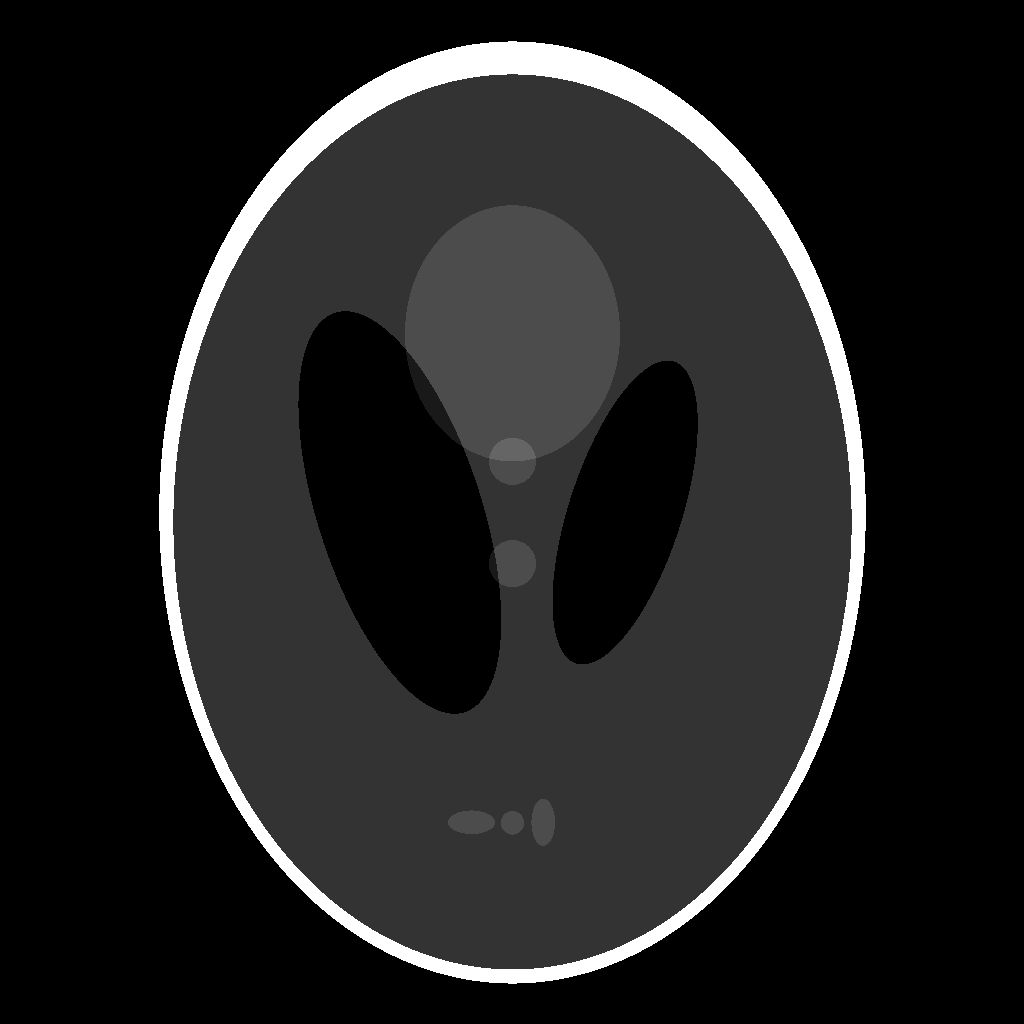

Obraz wynikowy:

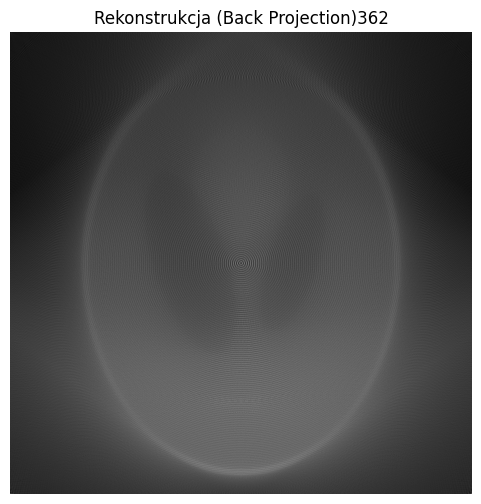

Obraz 2 wejściowy:

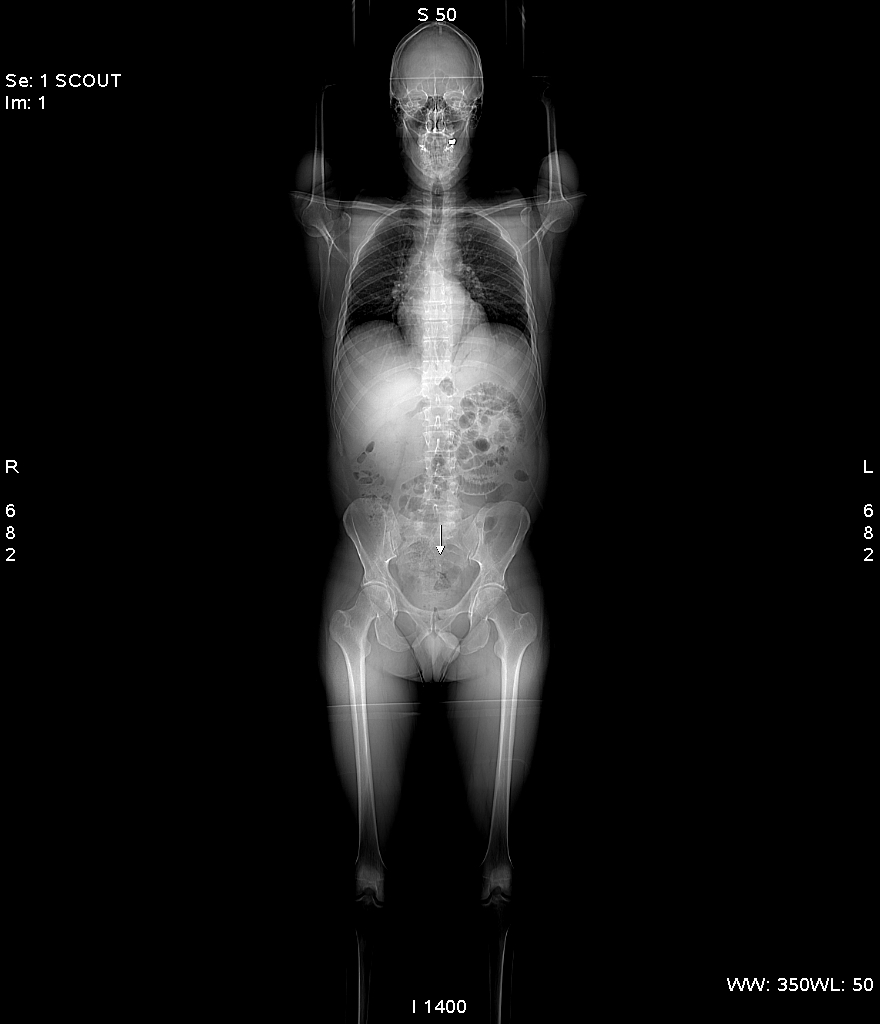

Obraz 2 wynikowy:

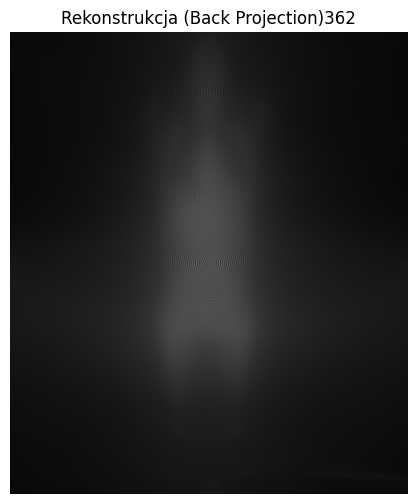